In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ecommerce_sales_analytics_5000.csv')
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [8]:
df.notna()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,True,True,True,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,True,True,True,True,True,True,True,True,True,True,True,True
4996,True,True,True,True,True,True,True,True,True,True,True,True
4997,True,True,True,True,True,True,True,True,True,True,True,True
4998,True,True,True,True,True,True,True,True,True,True,True,True


In [10]:
df.head(30)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56
5,10006,1/6/2022,1071,Electronics,West,2,264.44,0.20,Card,3,3.3,423.10
6,10007,1/7/2022,1700,Clothing,South,6,564.60,0.23,Card,1,1.8,2608.45
7,10008,1/8/2022,1020,Beauty,North,6,265.71,0.13,Card,2,3.7,1387.01
8,10009,1/9/2022,1614,Clothing,South,6,224.65,0.27,Card,2,1.4,983.97
9,10010,1/10/2022,1121,Clothing,West,4,272.71,0.06,Card,10,4.5,1025.39


In [12]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

<Axes: >

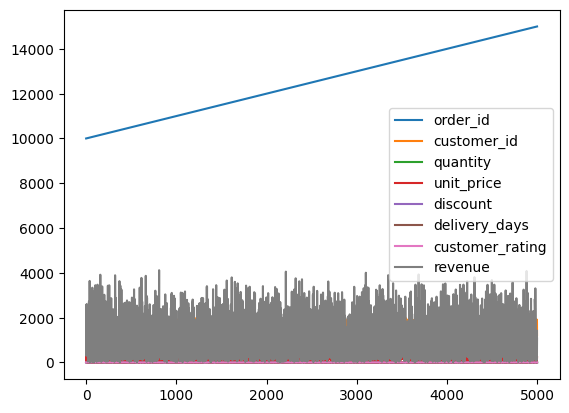

In [14]:
df.plot()

In [43]:
cat_rev = df.groupby('product_category')['revenue'].sum()
type(cat_rev)

pandas.core.series.Series

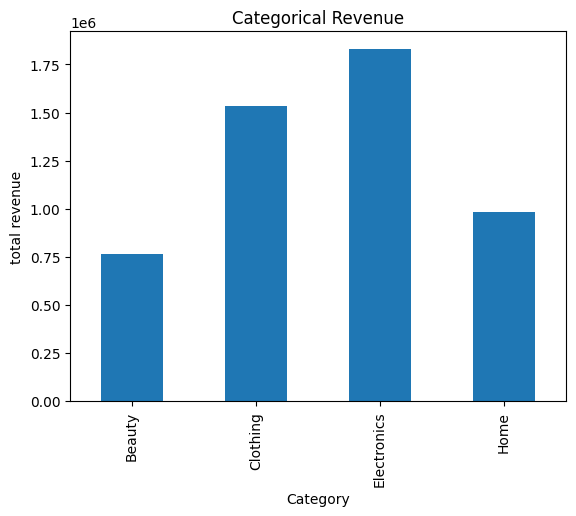

In [44]:
cat_rev.plot.bar()
plt.title('Categorical Revenue')
plt.xlabel('Category')
plt.ylabel("total revenue")
plt.show()

In [45]:
max_cat = df.groupby('product_category')['revenue'].max()

In [46]:
max_cat


product_category
Beauty         4005.93
Clothing       3928.63
Electronics    4119.33
Home           3640.56
Name: revenue, dtype: float64

In [47]:
mode_of_pay = df['payment_method'].value_counts()
mode_of_pay

payment_method
Card      2270
COD       1774
Wallet     956
Name: count, dtype: int64

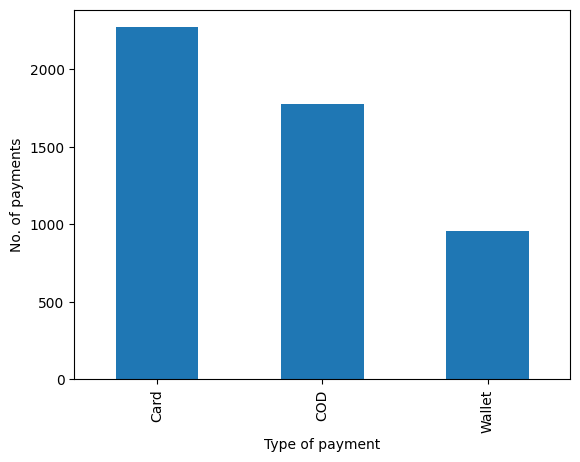

In [48]:
mode_of_pay.plot.bar()
plt.xlabel('Type of payment')
plt.ylabel('No. of payments')
plt.show()

In [36]:
rev_recieve = df.groupby('payment_method')['unit_price'].sum()
rev_recieve

payment_method
COD       549758.71
Card      703930.79
Wallet    288404.37
Name: unit_price, dtype: float64

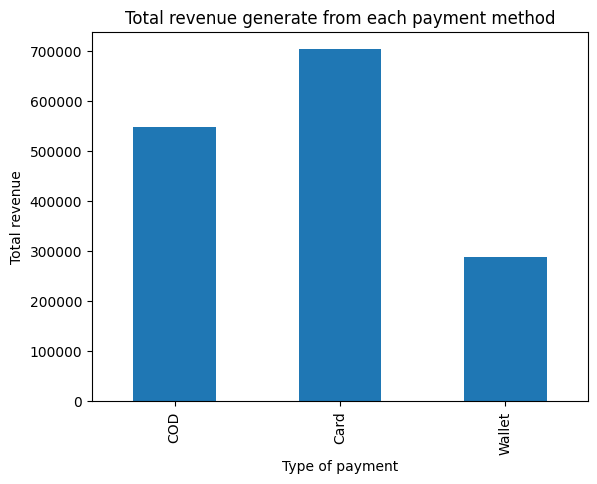

In [37]:
rev_recieve.plot.bar()
plt.xlabel('Type of payment')
plt.ylabel('Total revenue')
plt.title('Total revenue generate from each payment method')
plt.show()

In [38]:
df['region'].value_counts()

region
West     1289
North    1276
East     1227
South    1208
Name: count, dtype: int64

In [53]:
df['order_id'].duplicated().value_counts()

order_id
False    5000
Name: count, dtype: int64

In [55]:
df['customer_id'].duplicated().value_counts()

customer_id
True     4011
False     989
Name: count, dtype: int64

In [63]:
rev_from_cust = df[['customer_id',df.groupby('customer_id')['revenue'].sum()]]

rev_from_cust

TypeError: unhashable type: 'Series'

In [62]:
rev_from_cust.max()

17680.69

In [67]:
rev_from_cust[rev_from_cust == rev_from_cust.max()]

customer_id
1663    17680.69
Name: revenue, dtype: float64

In [68]:
df['discount'].max()

0.35

In [84]:
df.loc[(df['discount'] >= df['discount'].max()),['customer_id']]

,customer_id
94,1771
146,1418
210,1524
285,1641
400,1472
...,...
4774,1384
4786,1508
4837,1747
4962,1354


order_date
False    5000
Name: count, dtype: int64

In [90]:
region_wise_cat = df.groupby(['region','product_category']).count()

In [91]:
region_wise_cat

order_id  order_date  customer_id  quantity  \
region product_category                                                
East   Beauty                 165         165          165       165   
       Clothing               395         395          395       395   
       Electronics            418         418          418       418   
       Home                   249         249          249       249   
North  Beauty                 194         194          194       194   
       Clothing               378         378          378       378   
       Electronics            462         462          462       462   
       Home                   242         242          242       242   
South  Beauty                 172         172          172       172   
       Clothing               365         365          365       365   
       Electronics            455         455          455       455   
       Home                   216         216          216       216   
West   Beauty                 192         192          192       192   
       Clothing               393         393          393       393   
       Electronics            442         442          442       442   
       Home                   262         262          262       262   

                         unit_price  discount  payment_method  delivery_days  \
region product_category                                                        
East   Beauty                   165       165             165            165   
       Clothing                 395       395             395            395   
       Electronics              418       418             418            418   
       Home                     249       249             249            249   
North  Beauty                   194       194             194            194   
       Clothing                 378       378             378            378   
       Electronics              462       462             462            462   
       Home                     242       242             242            242   
South  Beauty                   172       172             172            172   
       Clothing                 365       365             365            365   
       Electronics              455       455             455            455   
       Home                     216       216             216            216   
West   Beauty                   192       192             192            192   
       Clothing                 393       393             393            393   
       Electronics              442       442             442            442   
       Home                     262       262             262            262   

                         customer_rating  revenue  
region product_category                            
East   Beauty                        165      165  
       Clothing                      395      395  
       Electronics                   418      418  
       Home                          249      249  
North  Beauty                        194      194  
       Clothing                      378      378  
       Electronics                   462      462  
       Home                          242      242  
South  Beauty                        172      172  
       Clothing                      365      365  
       Electronics                   455      455  
       Home                          216      216  
West   Beauty                        192      192  
       Clothing                      393      393  
       Electronics                   442      442  
       Home                          262      262

In [93]:
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

ValueError: The python kernel does not appear to be a conda environment.  Please use ``%pip install`` instead.